## EPL+Shear

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7, Tcmb0=0.0, Neff=3.04, m_nu=None, Ob0=0.0)

from ler.lens_galaxy_population import LensGalaxyParameterDistribution
from ler.utils import append_json, get_param_from_json

In [2]:
lens1 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="epl_shear_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="rejection_sampler_partial",
            cross_section="cross_section_epl_shear_njit",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_2.json
using ler availabl

In [3]:
lens2 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="epl_shear_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="importance_sampler_partial",
            cross_section="cross_section_epl_shear_njit",
        ),
    lens_functions_params=dict(
        cross_section_based_sampler=dict(
            n_prop=400,
            threshold_factor=1e-4,
            sigma_min=100.0,
            sigma_max=400.0,
            q_min=0.2,
            q_max=1.0,
            phi_min=0.0,
            phi_max=2 * np.pi,
            gamma_min=1.4,
            gamma_max=2.7,
            shear_min=-0.2,
            shear_max=0.2,
        ),
),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_2.json
using ler availabl

In [ ]:
lens3 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="epl_shear_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="rejection_sampler_full",
            cross_section="cross_section_epl_shear_njit",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)

In [ ]:
lens4 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="epl_shear_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="importance_sampler_full",
            cross_section="cross_section_epl_shear_njit",
        ),
    lens_functions_params=dict(
        cross_section_based_sampler=dict(
            n_prop=400,
            threshold_factor=1e-4,
            zs_min=0.001,
            zs_max=10.0,
            zl_min=0.0001,
            zl_max=None,
            sigma_min=100.0,
            sigma_max=400.0,
            q_min=0.2,
            q_max=1.0,
            phi_min=0.0,
            phi_max=2 * np.pi,
            gamma_min=1.4,
            gamma_max=2.7,
            shear_min=-0.2,
            shear_max=0.2,
        ),
    ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)

In [ ]:
# rejection_sampler_partial
param1 = lens1.sample_lens_parameters(50000)
# n=1000,time = 53.8 (+27.1 for njit initialization)

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [ ]:
# importance_sampler_partial
param2 = lens2.sample_lens_parameters(50000)
# n=1000,time = 2.3 (+19.9 for njit initialization)
# n=50000,time = 1m 58.9s (+19.9 for njit initialization)

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [18]:
# rejection_sampler_full
param3 = lens3.sample_lens_parameters(50000)
# time = 

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [19]:
# importance_sampler_full
param4 = lens4.sample_lens_parameters(50000)
# time = 

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [20]:
# keep only 'zs', 'zl', 'sigma'
param1 = {k: v for k, v in param1.items() if k in ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']}
param2 = {k: v for k, v in param2.items() if k in ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']}
param3 = {k: v for k, v in param3.items() if k in ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']}
param4 = {k: v for k, v in param4.items() if k in ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']}

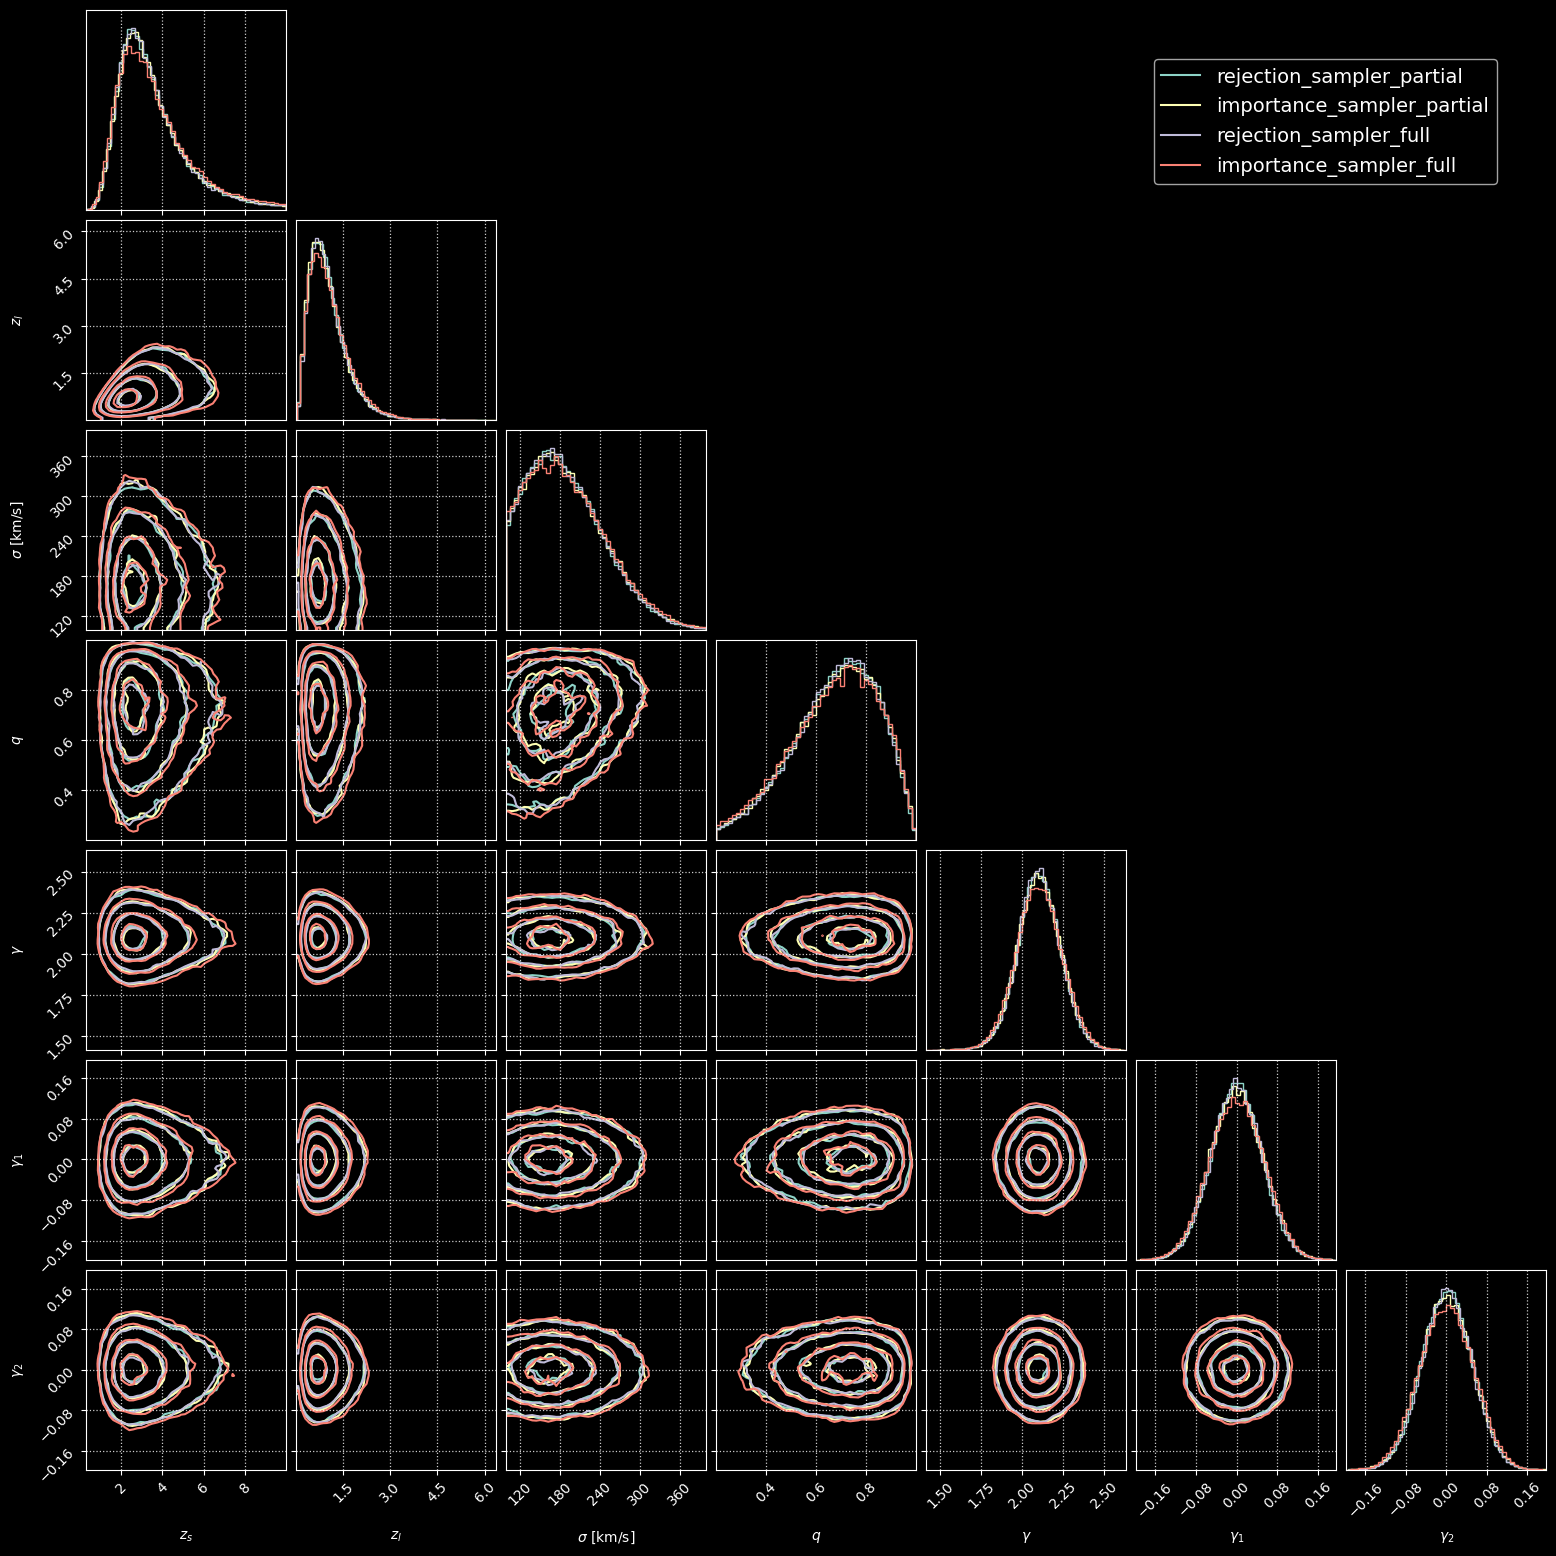

In [21]:
import corner
import matplotlib.lines as mlines

param_names = ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', '$q$', r'$\gamma$', r'$\gamma_1$', r'$\gamma_2$']

samples1 = np.stack([param1[p] for p in param_names], axis=1)
samples2 = np.stack([param2[p] for p in param_names], axis=1)
samples3 = np.stack([param3[p] for p in param_names], axis=1)
samples4 = np.stack([param4[p] for p in param_names], axis=1)

fig = corner.corner(
    samples1, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples2, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples3, 
    labels=labels, 
    color='C2', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples4, 
    labels=labels, 
    color='C3', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Add grid lines
for ax in fig.axes:
    ax.set_axisbelow(False)

    ax.grid(
        True,
        which='major',
        linestyle=':',
        linewidth=0.9,
        alpha=0.8,
        zorder=10,
    )

# Add legend
green_line = mlines.Line2D([], [], color='C0', label='rejection_sampler_partial')
blue_line = mlines.Line2D([], [], color='C1', label='importance_sampler_partial')
red_line = mlines.Line2D([], [], color='C2', label='rejection_sampler_full')
orange_line = mlines.Line2D([], [], color='C3', label='importance_sampler_full')
fig.legend(handles=[green_line, blue_line, red_line, orange_line], loc='upper right', 
           bbox_to_anchor=(0.95, 0.95), fontsize=14)
plt.show()


## KS Score

In [3]:
from ler.utils import KStest

ks_score = KStest(param3, param4)
print('#--------------------------------#')
print('KS Score between rejection_sampler_full and importance_sampler_full')
print('#--------------------------------#')
for key, value in ks_score.items(): 
    print(f'{key}: {value}')

ks_score = KStest(param3, param2)
print('#--------------------------------#')
print('KS Score between rejection_sampler_full and importance_sampler_partial')
print('#--------------------------------#') 
for key, value in ks_score.items():
    print(f'{key}: {value}')

ks_score = KStest(param3, param1)
print('#--------------------------------#')
print('KS Score between rejection_sampler_full and rejection_sampler_partial')
print('#--------------------------------#')
for key, value in ks_score.items():
    print(f'{key}: {value}')

ks_score = KStest(param1, param2)

#--------------------------------#
KS Score between rejection_sampler_full and importance_sampler_full
#--------------------------------#
gamma: {'D': 0.021660000000000013, 'pvalue': 1.2770315909285423e-10, 'n1': 50000, 'n2': 50000}
gamma1: {'D': 0.021680000000000005, 'pvalue': 1.2228403548849014e-10, 'n1': 50000, 'n2': 50000}
gamma2: {'D': 0.02178000000000002, 'pvalue': 9.838969898081783e-11, 'n1': 50000, 'n2': 50000}
q: {'D': 0.022540000000000004, 'pvalue': 1.8245461492322706e-11, 'n1': 50000, 'n2': 50000}
sigma: {'D': 0.02094000000000007, 'pvalue': 5.923421990148304e-10, 'n1': 50000, 'n2': 50000}
zl: {'D': 0.033499999999999974, 'pvalue': 8.243541720855047e-25, 'n1': 50000, 'n2': 50000}
zs: {'D': 0.03322000000000003, 'pvalue': 2.0992202461615156e-24, 'n1': 50000, 'n2': 50000}
#--------------------------------#
KS Score between rejection_sampler_full and importance_sampler_partial
#--------------------------------#
gamma: {'D': 0.01100000000000001, 'pvalue': 0.004680757565476653, 'n1'

# Result

KS Score between rejection_sampler_full and rejection_sampler_partial

| parameter |  KS (D) | p-value | interpretation  |
| --------- | ------: | ------: | --------------- |
| `gamma`   |  0.0070 |   0.172 | consistent      |
| `gamma1`  | 0.00484 |   0.600 | very consistent |
| `gamma2`  | 0.00404 |   0.808 | very consistent |
| `q`       | 0.00590 |   0.348 | consistent      |
| `sigma`   | 0.00474 |   0.626 | very consistent |
| `zl`      | 0.00420 |   0.768 | very consistent |
| `zs`      | 0.00698 |   0.174 | consistent      |


Your largest KS distance is Dmax~0.007 for gamma and zs. This means the largest visible CDF mismatch is only about 0.7\% . For n1=n2=50000, the expected random CDF fluctuation scale is roughly

$$\frac{1}{\sqrt{n_{\rm eff}}} = \frac{1}{\sqrt{25000}} \simeq 0.0063$$

So your observed largest deviations, D∼0.004 to 0.007, are basically at the level expected from ordinary Monte Carlo noise.

In [4]:
from ler.utils import save_json, load_json

# save_json('param1.json', param1)
# save_json('param2.json', param2)
# save_json('param3.json', param3)
# save_json('param4.json', param4)
param1 = load_json('param1.json')
param2 = load_json('param2.json')
param3 = load_json('param3.json')
param4 = load_json('param4.json')


## Lensed Vs Intrinsic

In [5]:
param_2_intrinsic = lens2.sample_all_routine_epl_shear_intrinsic(50000)

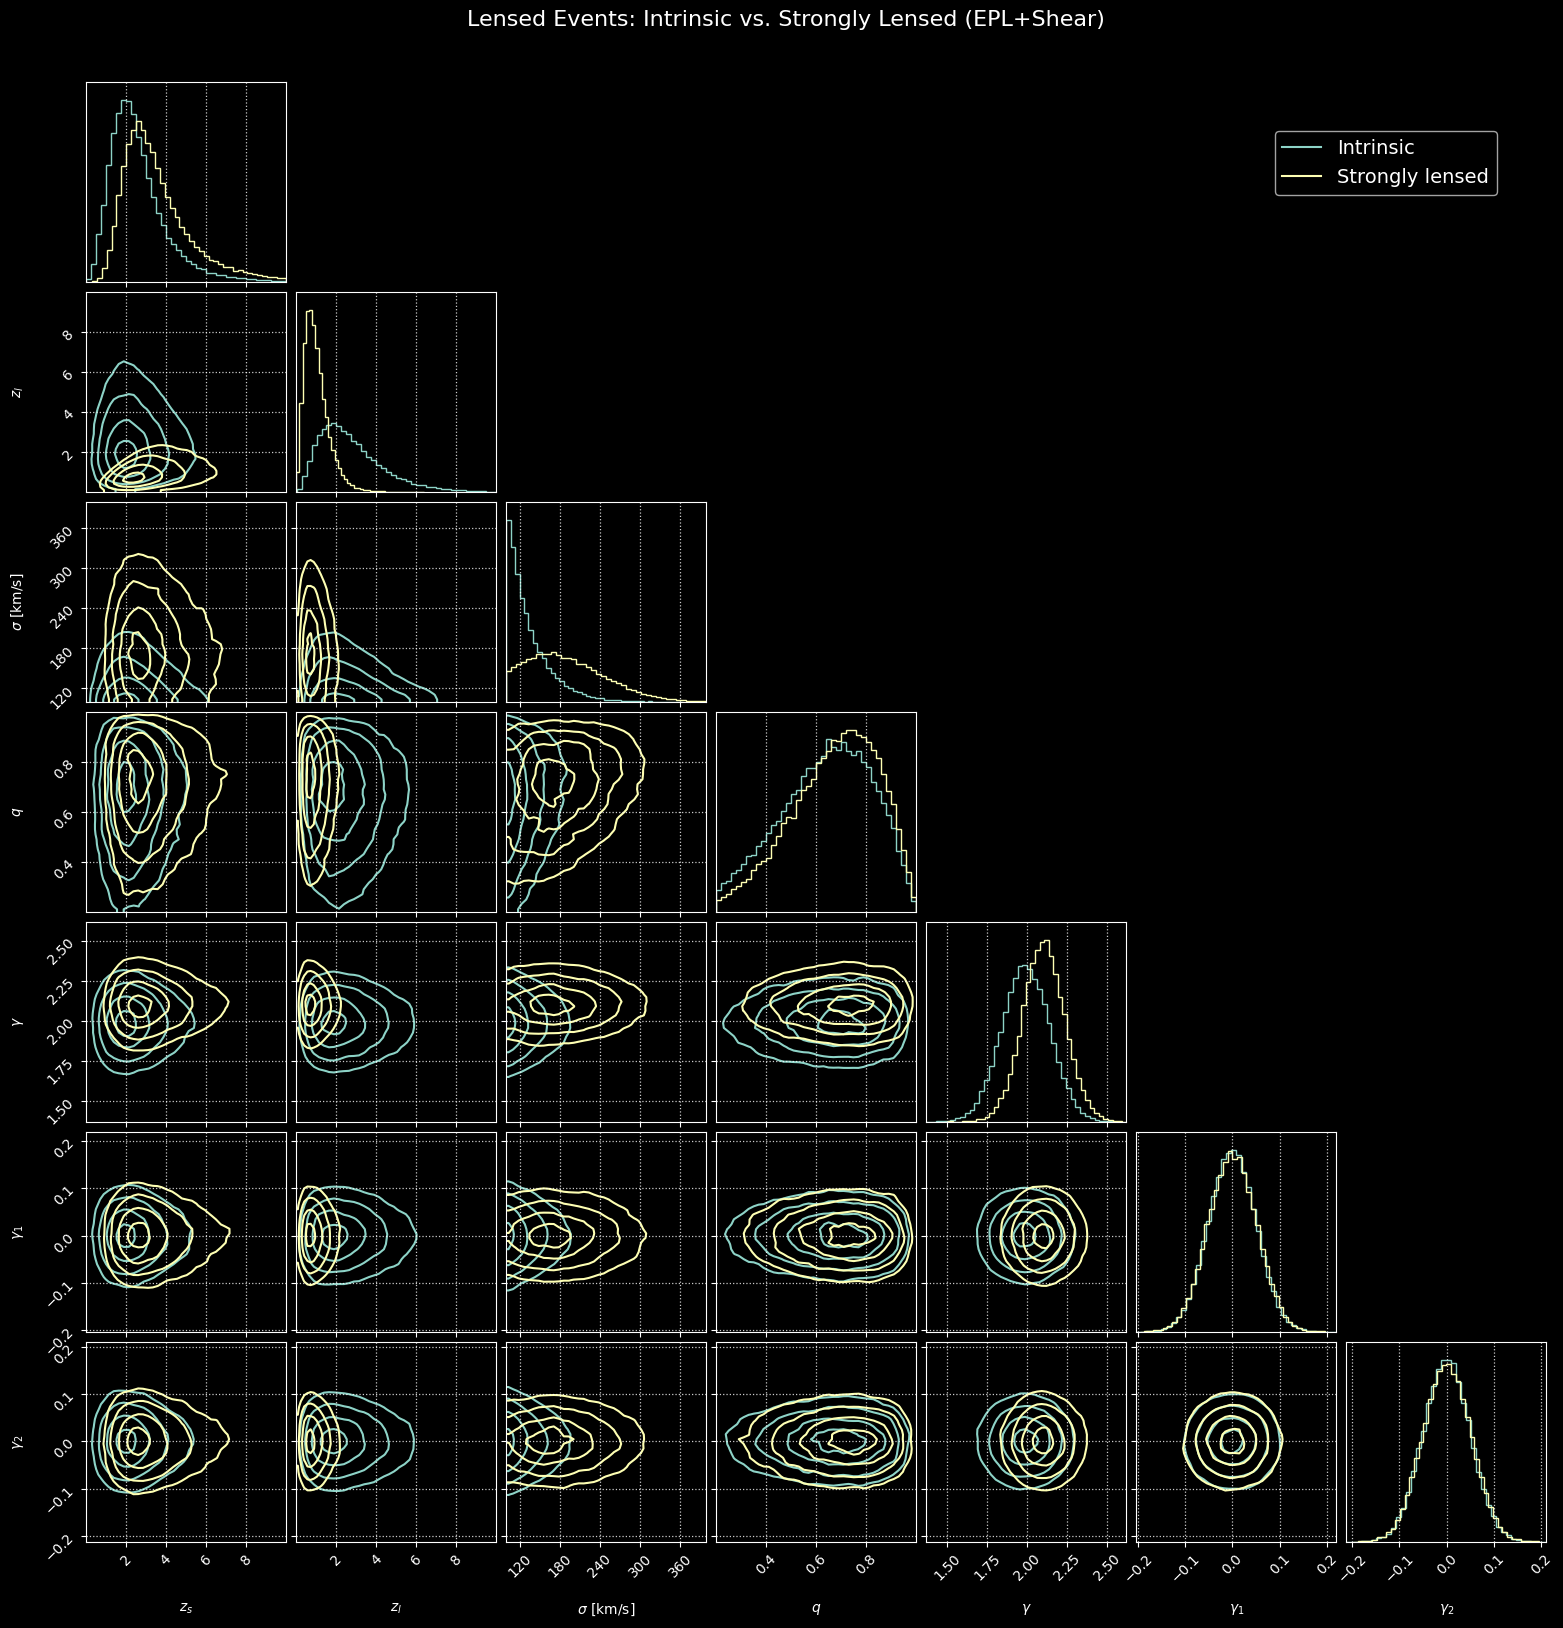

In [6]:
import corner
import matplotlib.lines as mlines

# Load data
param = param2
param_intrinsic = param_2_intrinsic

# Lensing-specific parameters to compare
param_names = ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', '$q$', '$\gamma$', '$\gamma_1$', '$\gamma_2$']

# Prepare data for corner plot
samples_intrinsic = np.stack([param_intrinsic[p] for p in param_names], axis=1)
samples_all = np.stack([param[p] for p in param_names], axis=1)

fig = corner.corner(
    samples_intrinsic, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    bins=40,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples_all, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    bins=40,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True},
    fig=fig,
)

# Add grid lines
for ax in fig.axes:
    ax.set_axisbelow(False)

    ax.grid(
        True,
        which='major',
        linestyle=':',
        linewidth=0.9,
        alpha=0.8,
        zorder=10,
    )

# Add legend
green_line = mlines.Line2D([], [], color='C0', label='Intrinsic')
blue_line = mlines.Line2D([], [], color='C1', label='Strongly lensed')
leg = fig.legend(
    handles=[green_line, blue_line],
    loc='upper right',
    bbox_to_anchor=(0.95, 0.95),
    fontsize=14,
)

fig.suptitle(
    'Lensed Events: Intrinsic vs. Strongly Lensed (EPL+Shear)',
    fontsize=16,
    y=1.02,
)

plt.show()